# Creating Plot data

In scene four, we plot for various curves the limit
in the conjecture.
The calculations of these graphs are done here
and the coordinates of points in the graph dumped
into a json file.

In [1]:
E = EllipticCurve([-4,1])
E.rank(), E.torsion_order(), E.local_data()


(2,
 1,
 [Local data at Principal ideal (2) of Integer Ring:
  Reduction type: bad additive
  Local minimal model: Elliptic Curve defined by y^2 = x^3 - 4*x + 1 over Rational Field
  Minimal discriminant valuation: 4
  Conductor exponent: 2
  Kodaira Symbol: IV
  Tamagawa Number: 3,
  Local data at Principal ideal (229) of Integer Ring:
  Reduction type: bad non-split multiplicative
  Local minimal model: Elliptic Curve defined by y^2 = x^3 - 4*x + 1 over Rational Field
  Minimal discriminant valuation: 1
  Conductor exponent: 1
  Kodaira Symbol: I1
  Tamagawa Number: 1])

In [3]:
def naive_height(Q):
    r"""
    return the naive projective height of a point on an elliptic curve
    """
    if Q[2] == 0:
        return ZZ(1)
    b = Q[1].numerator()
    c = Q[1].denominator()
    ae = Q[0] * c
    return max(abs(ae),abs(b),abs(c))

In [4]:
from itertools import product

def list_point_heights(E, B, hfunction = naive_height):
    """
    return a list of H(P) such that all values below B are included and a few more
    """
    tors = E.torsion_points()
    r = E.rank()
    if r == 0:
        return [hfunction(Q) for Q in tors]
    res = []
    # find the bound mm up to which we calculate the heights
    mat = E.height_pairing_matrix().change_ring(RDF)
    mu = log(B*1.)/min(mat.eigenvalues())
    mu = 1.1*sqrt(mu) + 1
    mm = ZZ(ceil(mu))
    for ais in product( srange(1-mm,mm), repeat=r):   # nested loops from itertools
        Q = sum(ais[i]*E.gens()[i] for i in srange(r))
        res += [hfunction(Q+T) for T in tors]
    return res

In [5]:
[len([P for P in list_point_heights(E,10^i) if P<10^i]) for i in [1..5]]

[5, 7, 7, 9, 9]

In [6]:
def tabulate_point_heights(E,B,hfunction=naive_height):
    """
    return a list of [x, Count H(x)] at all x where H steps up
    """
    li = list_point_heights(E,B,hfunction=hfunction)
    li.sort()
    ta = []
    for i,x in enumerate(li):
        if x>B or i == len(li) - 1:
            return ta
        if x!=li[i+1]:
            ta.append([x,i+1])

In [7]:
def n_hbound(E, B):
    r"""
    return the number of points on E of height bounded by B
    """
    if B<1:
        return ZZ(0)
    return sum(map( lambda x: x<B, list_point_heights(E,B)))

In [8]:
def solmod(E, Q):
    r"""
    Return to number of solutions modulo Q using the proposition via the explicit blow ups
    """
    M = ZZ(1)  # stores the result
    if Q in ZZ:
        ff = Q.factor()
    else:
        ff = Q # we suppose a factorisation was given
    for p, n in ff:
        M *= solmodpn(E,p,n)
    return M


def solmodpn(E, p, n):
    D = E.discriminant()
    if D%p == 0:
        da = E.local_data(p)
        k = da.kodaira_symbol()
        c = da.tamagawa_number()
        pk = k._pari_code()
        if pk == 2: # II
            M0 = p if n>=2 else p+1
        elif pk == 3: #III
            M0 = 2*p if n >= 2 else p+1
        elif pk == 4: # IV
            if n == 1:
                M0 = p+1
            elif n == 2:
                M0 = 2*p
            else:
                M0 = c*p
        elif pk == -4 : # IV*
            if n == 1:
                M0 = p+1
            elif n in [2,3,4]:
                M0 = 2*p
            else: # n >= 5:
                M0 = c*p
        elif pk == -3 : # III*
            M0 = c*p if n >= 1 else p+1
        elif pk == -2: # II*
            if n == 1:
                M0 = p+1
            elif n in [2,3,4,5]:
                M0 = 2*p
            else:  # n >= 6:
                M0 = p
        elif pk > 4 : # I_m
            m = pk - 4
            if da.has_split_multiplicative_reduction():
                M0 = m*(p-1) if n >= m+1 else (p-1)*n+1
            else : # non split
                if n >= m+1:
                    M0 = c*(p+1)
                else:
                    M0 =  p+2 if n%2 == 1 else 2*p+1
        elif pk < -4: # I*_m
            m = -pk - 4
            if n == 1:
                M0 = p+1
            elif n >= m+4:
                M0 = c*p
            elif n in [2,3]:
                M0 = 2*p
            else: # 4<=n<=m+3
                M0 = 3*p
    else:  # good reduction I_0
        M0 = E.Np(p)
    M = M0 * p**(n-1)
    return M


def solmodacc(E,p,n):
    """
    return the number of points of E modulo p^n assuming that n>= n0, i.e. Q is acceptable.
    """
    D = E.discriminant()
    if D%p != 0:
        return E.Np(p) * p**(n-1)
    else:
        return E.tamagawa_number(p) * (p-E.ap(p)) * p**(n-1)


In [8]:
[solmod(E,Q) for Q in [2,3,4,5,6,7,8,9,10]]

[3, 7, 8, 9, 21, 12, 24, 21, 27]

In [9]:
def naive_quot(E,B):
    r"""
    Return the quotient on naive bsd up to bound B
    """
    B = ZZ(B)
    ps = prime_range(B)
    ff = [[p,1] for p in ps]
    l = prod(ps)
    #print(l)
    l *=  (n_hbound(E,B))**2
    #print(l)
    l = l/solmod(E,ff)
    return l

def listseq(E, B, step=100):
    r"""
    Return a list to use in graph of the quotient
    """
    MperQ = 1.
    cu = step
    li = []
    hs = list_point_heights(E,B)
    for p in prime_range(B):
        MperQ *= solmodacc(E,p,1)/p
        if p > cu:
            hb = sum(map( lambda x: x<p, hs))
            li.append([p,hb**2/MperQ])
            cu += step
    return(li)

In [10]:
def list_of_points_for_focus_shifting(E, B=10^7):
    r"""
    Creates a list of points to plot but with more points for
    smaller T
    """
    MperQ = 1.
    # step = 10
    li = []
    hs = list_point_heights(E,B)
    print(f"done calulating points, there are {len(hs)}")
    cu = 10    
    for p in prime_range(B):
        MperQ *= solmodacc(E,p,1)/p
        if p < 1000:
            hb = sum(map( lambda x: x<p, hs))
            li.append([p,hb**2/MperQ])
        if p > cu:
            hb = sum(map( lambda x: x<p, hs))
            li.append([p,hb**2/MperQ])
            cu += max(p/1000,10)
    return li

done calulating points, there are 841
10381


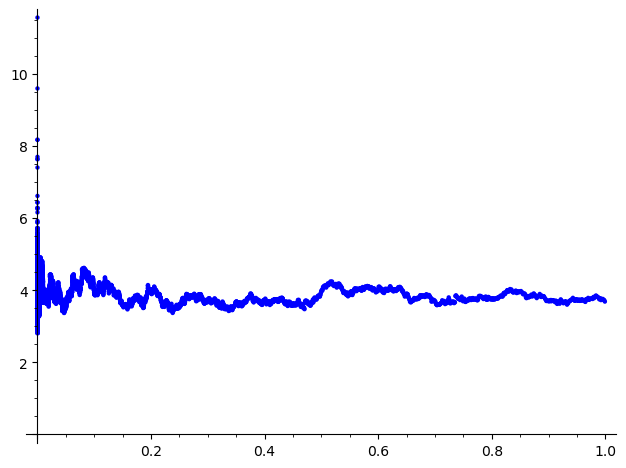

In [11]:
li = list_of_points_for_focus_shifting(E, 10^8)
print(len(li))
list_plot(li, ymin=0)

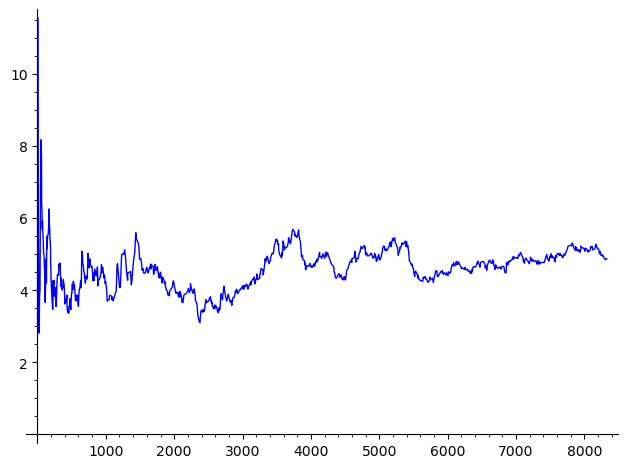

In [12]:
list_plot(li[:1000],plotjoined=True,ymin=0)

In [13]:
li[-1]

[99907133, 3.68478912539386]

In [14]:
import json

lij = [ [int(a[0]), float(a[1])] for a in li]

with open("plotpts_curve_rk2.json", "w") as f:
    json.dump(lij, f)


In [ ]:
for aa in [-4..4]:
    E = EllipticCurve([aa,1])
    print(aa,E.rank(), E.torsion_order(), E.label())
    li =  list_of_points_for_focus_shifting(E, 10^9)
    print(len(li))
    lij = [ [int(a[0]), float(a[1])] for a in li]
    with open(f"plotpts_curve_aa{aa}_up_to_9.json", "w") as f:
        json.dump(lij, f)
    print("done")

-4 2 1 916c1
done calulating points, there are 961


In [ ]:
list_plot(li,ymin=0)

In [19]:
for aa in [-4..4]:
    E = EllipticCurve([aa,1])
    print(E.conductor().factor(), E.tamagawa_numbers())

2^2 * 229 [3, 1]
2^4 * 3^4 [1, 1]
2^3 * 5 [2, 1]
2^2 * 23 [3, 1]
2^2 * 3^2 [3, 2]
2^4 * 31 [1, 1]
2^3 * 59 [2, 1]
2^2 * 3^3 * 5 [1, 1, 1]
2^2 * 283 [3, 1]


## Find jumps to point out in the last curve shown

In [2]:
E = EllipticCurve([4,1])
E.rank(), E.torsion_order()

(1, 1)

In [11]:
tabulate_point_heights(E,10^9)

[[1, 3], [9, 5], [37, 7], [1135, 9], [137593, 11], [3241792, 13]]

In [13]:
[i*E.gens()[0] for i in [1..9]]

[(0 : 1 : 1),
 (4 : -9 : 1),
 (9/4 : 37/8 : 1),
 (28/81 : -1135/729 : 1),
 (2664/49 : 137593/343 : 1),
 (-4319/21904 : 1462833/3241792 : 1),
 (3023640/380689 : -5426904023/234885113 : 1),
 (132292204/104346225 : 3035304434017/1065896688375 : 1),
 (9838587465/11493126436 : -2769277201533179/1232132112697816 : 1)]

done calulating points, there are 21
12685


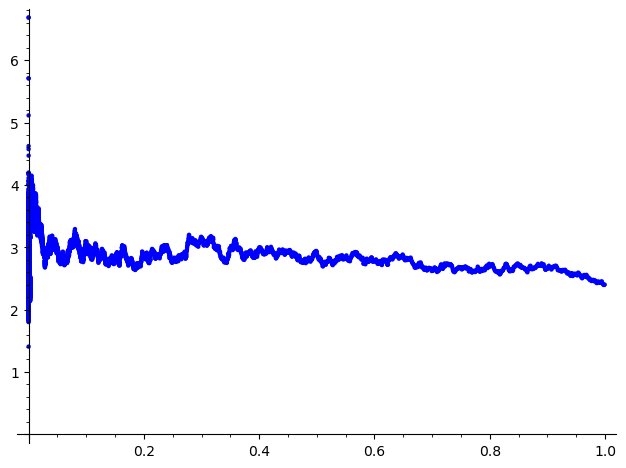

In [14]:
li = list_of_points_for_focus_shifting(E, 10^9)
print(len(li))
list_plot(li, ymin=0)

In [15]:
li[-1]

[999334793, 2.40103057892155]

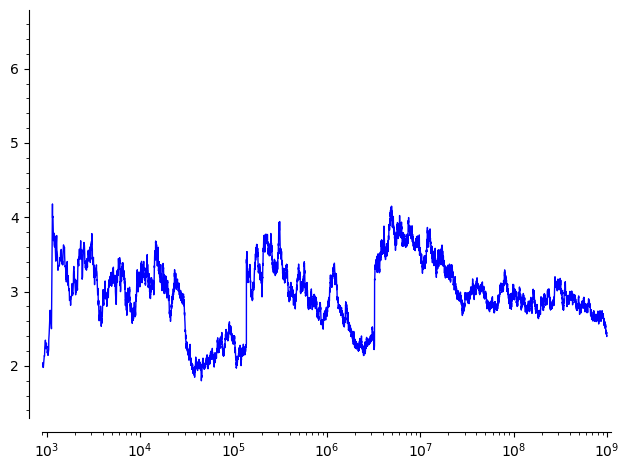

In [18]:
list_plot(li, scale="semilogx", xmin=1000, plotjoined=True)

## adjust graphs now without point count

In [22]:
def log_list_of_points_for_focus_shifting(E, B=10^7):
    r"""
    Creates a list of points to plot but with more points for
    smaller T
    But now compared to log(T)^r rather than N(T)^2
    """
    r = E.rank(use_database=True)
    MperQ = 1.
    li = []
    cu = 10    
    for p in prime_range(B):
        MperQ *= solmodacc(E,p,1)/p
        if p < 1000:
            lt = log(p*1.)^r
            li.append([p,lt/MperQ])
        if p > cu:
            lt = log(p*1.)^r
            li.append([p,lt/MperQ])
            cu += max(p/1000,10)
    return li

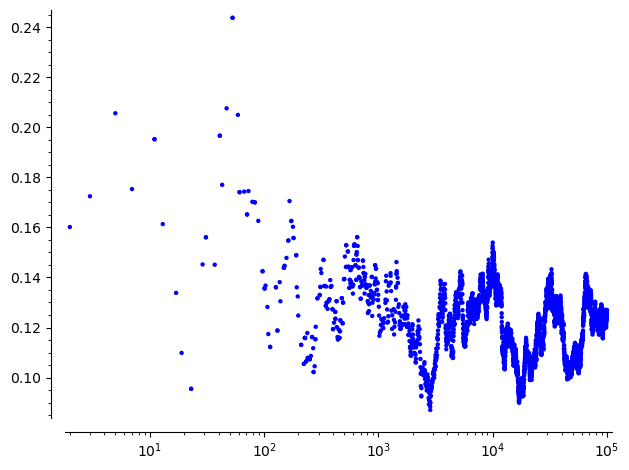

In [23]:
li = log_list_of_points_for_focus_shifting(EllipticCurve([-4,1]), 10^5)
list_plot(li, scale="semilogx")

In [24]:
for aa in [-4..4]:
    E = EllipticCurve([aa,1])
    print(aa, E.rank(), E.torsion_order(), E.label())
    li =  log_list_of_points_for_focus_shifting(E, 10^9)
    print(len(li))
    lij = [ [int(a[0]), float(a[1])] for a in li]
    with open(f"logplotpts_curve_aa{aa}_up_to_9.json", "w") as f:
        json.dump(lij, f)
    print("done")

-4 2 1 916c1
12685


NameError: name 'json' is not defined

In [25]:
import json

In [26]:
with open(f"logplotpts_curve_aa{aa}_up_to_9.json", "w") as f:
        json.dump(lij, f)

In [27]:
for aa in [-3..4]:
    E = EllipticCurve([aa,1])
    print(aa, E.rank(), E.torsion_order(), E.label())
    li =  log_list_of_points_for_focus_shifting(E, 10^9)
    print(len(li))
    lij = [ [int(a[0]), float(a[1])] for a in li]
    with open(f"logplotpts_curve_aa{aa}_up_to_9.json", "w") as f:
        json.dump(lij, f)
    print("done")

-3 1 1 1296c1
12685
done
-2 0 4 40a3
12685
done
-1 1 1 92b1
12685
done
0 0 6 36a1
12685
done
1 1 1 496a1
12685
done
2 1 1 472a1
12685
done
3 1 1 540b1
12685
done
4 1 1 1132b1
12685
done


## Graphs for the singular curve

In [46]:
def naive_count(p, n):
    A = Zmod(p^n)
    res = p^(n-1) # pts at oo
    for x in A:
        a = x^2*(x+3)
        if a.is_square():
            res += len(a.sqrt(all=True))
            
    return res

In [47]:
for p in prime_range(100):
    print( (p, naive_count(p,2), 2*p^2-p*kronecker(3,p)) , end = ", ")


(2, 8, 10), (3, 18, 18), (5, 55, 55), (7, 105, 105), (11, 231, 231), (13, 325, 325), (17, 595, 595), (19, 741, 741), (23, 1035, 1035), (29, 1711, 1711), (31, 1953, 1953), (37, 2701, 2701), (41, 3403, 3403), (43, 3741, 3741), (47, 4371, 4371), (53, 5671, 5671), (59, 6903, 6903), (61, 7381, 7381), (67, 9045, 9045), (71, 10011, 10011), (73, 10585, 10585), (79, 12561, 12561), (83, 13695, 13695), (89, 15931, 15931), (97, 18721, 18721), 

In [58]:
for p in prime_range(100):
    print( (p, naive_count(p,3), p^2*(2*p+kronecker(3,p)*(p-2)) ) , end = ", ")

(2, 16, 16), (3, 54, 54), (5, 175, 175), (7, 441, 441), (11, 3751, 3751), (13, 6253, 6253), (17, 5491, 5491), (19, 7581, 7581), (23, 35443, 35443), (29, 26071, 26071), (31, 31713, 31713), (37, 149221, 149221), (41, 72283, 72283), (43, 83205, 83205), (47, 307051, 307051), (53, 154495, 154495), (59, 609175, 609175), (61, 673501, 673501), (67, 309741, 309741), (71, 1063651, 1063651), (73, 1156393, 1156393), (79, 505521, 505521), (83, 1701583, 1701583), (89, 720811, 720811), (97, 2719201, 2719201), 

In [60]:
for p in prime_range(50):
    print( (p, naive_count(p,4), p^3*(3*p-1+kronecker(3,p)*(p-2)) ) , end = ", ")

(2, 48, 40), (3, 243, 216), (5, 1375, 1375), (7, 5145, 5145), (11, 54571, 54571), (13, 107653, 107653), (17, 171955, 171955), (19, 267501, 267501), (23, 1082863, 1082863), (29, 1438951, 1438951), (31, 1876833, 1876833), (37, 7344685, 7344685), (41, 5720443, 5720443), (43, 6917109, 6917109), (47, 19207255, 19207255), 

In [69]:
def better_count_fixed_val(p,n,k):
    """
    return the number of solutions to y^2 = x^2(x+3) modulo p^n such that ord_p(x) = k
    """
    if 2*k >= n:
        if n%2 == 0:
            return (p-1)*p^(k-1)*p^(n/2)
        else:
            return (p-1)*p^(k-1)*p^((n-1)/2)
    elif k>0:
        return (p-1)*(1+kronecker(3,p))*p^(n-1)
    else:
        raise ValueError

In [70]:
def better_count(p,n):
    if p < 4:
        raise ValueError
    res = (p-kronecker(3,p))*p^(n-1)
    for k in [1..n]:
        res += better_count_fixed_val(p,n,k)
    return res


In [71]:
for p in prime_range(4,10):
    for n in [1..5]:
        print(f"{p}^{n} : {better_count(p,n)}, {naive_count(p,n)}")

5^1 : 10, 7
5^2 : 150, 55
5^3 : 750, 175
5^4 : 16250, 1375
5^5 : 81250, 4375
7^1 : 14, 9
7^2 : 392, 105
7^3 : 2744, 441
7^4 : 120050, 5145
7^5 : 840350, 21609
